# Assignment 1 – Foundations & Tensor Operations

| Field | Details |
|---|---|
| **Student Name** | Sachin Shrestha |
| **Student ID** | 032338-22 |
| **Date** | 5th April 2026 |

---
## 1. Objective

- Demonstrate tensor creation, reshaping, and broadcasting using NumPy and PyTorch.
- Implement core linear algebra operations: matrix multiplication and eigenvalue decomposition.
- Explore probability concepts: entropy and distributions.
- Compare manual implementations with library-based approaches.
- Investigate numerical instability and floating-point precision issues.

---
## 2. Theoretical Background

A **tensor** is a generalization of scalars, vectors, and matrices to arbitrary dimensions (axes). In ML:
- 0-D Tensor (Scalar): A single number, e.g., a loss value.
- 1-D Tensor (Vector): A 1D array, e.g., a feature vector `[x₁, x₂, ..., xₙ]`.
- 2-D Tensor (Matrix): Rows × Columns, e.g., a weight matrix `W ∈ ℝ^(m×n)`.
- 3-D+ Tensor: e.g., a batch of images (batch, height, width, channels).

**Matrix Multiplication:** For `A ∈ ℝ^(m×k)` and `B ∈ ℝ^(k×n)`:
$$C_{ij} = \sum_{l=1}^{k} A_{il} \cdot B_{lj}$$

**Eigenvalue Decomposition:** If `Av = λv`, then `λ` is an eigenvalue and `v` its eigenvector. Used in PCA and covariance analysis.

**Shannon Entropy:** Measures uncertainty in a distribution:
$$H(X) = -\sum_{i} p(x_i) \log_2 p(x_i)$$

**Numerical Stability:** float32 has ~7 decimal digits of precision. Large inputs to `exp()` cause overflow. The log-sum-exp trick stabilises softmax by subtracting the maximum value before applying `exp`.

---
## 3. Dataset

- Core operations (Sections 4.1–4.4) use **synthetically generated** tensors (manually defined arrays and random tensors) — no external data needed.
- **Experiment 3** introduces the **Iris dataset** (via `sklearn.datasets.load_iris`) as a realistic ML context:
  - 150 samples, 4 features (sepal/petal length and width), 3 classes (setosa, versicolor, virginica).
  - Features are standardised (zero mean, unit variance) before use.
  - 80/20 stratified train/test split: 120 training samples, 30 test samples.

---
## 4. Implementation

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)
print(f'NumPy {np.__version__} | PyTorch {torch.__version__}')

NumPy 1.26.4 | PyTorch 2.9.1+cpu


### 4.1 Tensor Creation

In [16]:
# NumPy tensors
np_vector = np.array([1., 2., 3., 4.])
np_matrix = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
np_3d     = np.random.randn(2, 3, 4).astype(np.float32)
np_eye    = np.eye(3)

print('[NumPy]')
print(f'Vector {np_vector.shape}:\n{np_vector}')
print(f'\nMatrix {np_matrix.shape}:\n{np_matrix}')
print(f'\n3-D Tensor {np_3d.shape}:\n{np_3d}')
print(f'\nIdentity 3x3:\n{np_eye}')

# PyTorch tensors
pt_matrix  = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
pt_from_np = torch.from_numpy(np_matrix)   # NumPy <-> PyTorch bridge

print('\n[PyTorch]')
print(f'Matrix {pt_matrix.shape} dtype={pt_matrix.dtype}:\n{pt_matrix}')
print(f'\nFrom NumPy {pt_from_np.shape} (bridge works ✓):\n{pt_from_np}')

[NumPy]
Vector (4,):
[1. 2. 3. 4.]

Matrix (2, 3):
[[1. 2. 3.]
 [4. 5. 6.]]

3-D Tensor (2, 3, 4):
[[[ 0.49671414 -0.1382643   0.64768857  1.5230298 ]
  [-0.23415338 -0.23413695  1.5792128   0.7674347 ]
  [-0.46947438  0.54256004 -0.46341768 -0.46572974]]

 [[ 0.24196227 -1.9132802  -1.7249179  -0.5622875 ]
  [-1.0128311   0.31424734 -0.9080241  -1.4123037 ]
  [ 1.4656488  -0.2257763   0.0675282  -1.4247482 ]]]

Identity 3x3:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

[PyTorch]
Matrix torch.Size([2, 3]) dtype=torch.float32:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

From NumPy torch.Size([2, 3]) (bridge works ✓):
tensor([[1., 2., 3.],
        [4., 5., 6.]])


### 4.2 Reshaping & Broadcasting

In [17]:
# Reshaping
orig = np.arange(12, dtype=np.float32)
print(f'Original: {orig}')
print(f'Reshaped (3,4):\n{orig.reshape(3,4)}')
print(f'Reshaped (2,3,2):\n{orig.reshape(2,3,2)}')
print(f'Transpose (3,4) -> (4,3): \n{orig.reshape(3,4).T}')

#PyTorch reshaping — identical rules
print(f'PyTorch view(3,4):\n{torch.arange(12.).view(3,4)}')
print(f'PyTorch view(2,3,2):\n{torch.arange(12.).view(2,3,2)}')
print(f'PyTorch Transpose (3,4) -> (4,3):\n{torch.arange(12.).view(3,4).T}')


# Broadcasting
M   = np.array([[1., 2., 3.], [4., 5., 6.]])
row = np.array([[0, 1, 2]])     # (1,3)
col = np.array([[0],[10],[20]]) # (3,1)
print(f'\nMatrix M (2×3):\n{M}')
print(f'\nM + 10:\n{M + 10}')
print(f'\nrow + col -> {(row+col).shape}:\n{row+col}')

# PyTorch broadcasting — identical rules
pt_M   = torch.tensor(M)
pt_row = torch.tensor(row, dtype=torch.float32)
pt_col = torch.tensor(col, dtype=torch.float32)
print(f'\nPyTorch row+col broadcast:\n{pt_row + pt_col}')

# Batch normalisation analogy
batch    = np.random.randn(32, 4).astype(np.float32)   # 32 samples, 4 features
mean_vec = batch.mean(axis=0)                           # (4,)
std_vec  = batch.std(axis=0)  + 1e-8                   # (4,)  avoid /0
normed   = (batch - mean_vec) / std_vec                 # broadcast (32,4)-(4,)
print(f'\nBatch normalisation analogy (32,4) tensor:')
print(f'  mean: {mean_vec.round(4)}')
print(f'  std : {std_vec.round(4)}')
print(f'  normed shape: {normed.shape}  | mean≈{normed.mean(0).round(4)}  std≈{normed.std(0).round(4)}')

Original: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Reshaped (3,4):
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
Reshaped (2,3,2):
[[[ 0.  1.]
  [ 2.  3.]
  [ 4.  5.]]

 [[ 6.  7.]
  [ 8.  9.]
  [10. 11.]]]
Transpose (3,4) -> (4,3): 
[[ 0.  4.  8.]
 [ 1.  5.  9.]
 [ 2.  6. 10.]
 [ 3.  7. 11.]]
PyTorch view(3,4):
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
PyTorch view(2,3,2):
tensor([[[ 0.,  1.],
         [ 2.,  3.],
         [ 4.,  5.]],

        [[ 6.,  7.],
         [ 8.,  9.],
         [10., 11.]]])
PyTorch Transpose (3,4) -> (4,3):
tensor([[ 0.,  4.,  8.],
        [ 1.,  5.,  9.],
        [ 2.,  6., 10.],
        [ 3.,  7., 11.]])

Matrix M (2×3):
[[1. 2. 3.]
 [4. 5. 6.]]

M + 10:
[[11. 12. 13.]
 [14. 15. 16.]]

row + col -> (3, 3):
[[ 0  1  2]
 [10 11 12]
 [20 21 22]]

PyTorch row+col broadcast:
tensor([[ 0.,  1.,  2.],
        [10., 11., 12.],
        [20., 21., 22.]])

Batch normalisation analogy (32,4) tensor:

### 4.3 Matrix Multiplication

In [18]:
def matmul_manual(A, B):
    m, k = A.shape; _, n = B.shape
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for l in range(k):
                C[i,j] += A[i,l] * B[l,j]
    return C

A = np.array([[1,2,3],[4,5,6]], dtype=float)  # 2x3
B = np.array([[7,8],[9,10],[11,12]], dtype=float)  # 3x2

print(f'A {A.shape}:\n{A}')
print(f'\nB {B.shape}:\n{B}')
print(f'\nC = A @ B (NumPy):\n{A @ B}')
print(f'C = A @ B (manual):\n{matmul_manual(A, B)}')
print(f'C = A @ B (PyTorch):\n{torch.tensor(A) @ torch.tensor(B)}')
print(f'\nMax absolute diff (manual vs NumPy) : {np.max(np.abs(matmul_manual(A, B) - (A @ B))):.2e}')
print(f'Max absolute diff (NumPy  vs PyTorch): {np.max(np.abs((A @ B) - (torch.tensor(A) @ torch.tensor(B)).numpy())):.2e}')

# Element-wise vs matmul
X = np.array([[1,2],[3,4]], dtype=float)
Y = np.array([[5,6],[7,8]], dtype=float)
print(f'\nX * Y (element-wise):\n{X*Y}')
print(f'X @ Y (matrix mult):\n{X@Y}')

A (2, 3):
[[1. 2. 3.]
 [4. 5. 6.]]

B (3, 2):
[[ 7.  8.]
 [ 9. 10.]
 [11. 12.]]

C = A @ B (NumPy):
[[ 58.  64.]
 [139. 154.]]
C = A @ B (manual):
[[ 58.  64.]
 [139. 154.]]
C = A @ B (PyTorch):
tensor([[ 58.,  64.],
        [139., 154.]], dtype=torch.float64)

Max absolute diff (manual vs NumPy) : 0.00e+00
Max absolute diff (NumPy  vs PyTorch): 0.00e+00

X * Y (element-wise):
[[ 5. 12.]
 [21. 32.]]
X @ Y (matrix mult):
[[19. 22.]
 [43. 50.]]


### 4.4 Eigenvalue Decomposition

In [19]:
# Simple symmetric matrix 
A = np.array([[4, 2, 1],
               [2, 5, 3],
               [1, 3, 6]], dtype=float)

eigvals, eigvecs = np.linalg.eig(A)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

print(f'Matrix A:\n{A}')
print(f'\nEigenvalues  : {eigvals.round(4)}')
print(f'Eigenvectors (columns):\n{eigvecs.round(4)}')
print(f'\nVerify Av = λv, max error: {np.max(np.abs(A @ eigvecs[:,0] - eigvals[0]*eigvecs[:,0])):.2e}')

# PyTorch equivalent
pt_eigvals, _ = torch.linalg.eig(torch.tensor(A))
print(f'\nPyTorch eigenvalues (real): {pt_eigvals.real.numpy().round(4)}')

Matrix A:
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

Eigenvalues  : [9.3485 3.7302 1.9213]
Eigenvectors (columns):
[[-0.3651 -0.7759  0.5145]
 [-0.6366 -0.1953 -0.7461]
 [-0.6793  0.5999  0.4226]]

Verify Av = λv, max error: 4.44e-15

PyTorch eigenvalues (real): [9.3485 3.7302 1.9213]


---
## 5. Experiments

### Experiment 1 — Softmax Numerical Instability

In [20]:
np.seterr(over='ignore', invalid='ignore')  # suppress warnings

def softmax_naive(z):
    e = np.exp(np.asarray(z, dtype=np.float64)); return e / e.sum()

def softmax_stable(z):
    z = np.asarray(z, dtype=np.float64); e = np.exp(z - z.max()); return e / e.sum()

for name, z in [('Normal [1,2,3]',[1.,2.,3.]), ('Large [100,200,300]',[100.,200.,300.]), ('Huge [1000,2000,3000]',[1000.,2000.,3000.])]:
    n, s = softmax_naive(z), softmax_stable(z)
    print(f'{name}')
    print(f'  Naive : {n}  [{"⚠ NaN/Inf!" if not np.all(np.isfinite(n)) else "ok"}]')
    print(f'  Stable: {s}  [ok]\n')

Normal [1,2,3]
  Naive : [0.09003057 0.24472847 0.66524096]  [ok]
  Stable: [0.09003057 0.24472847 0.66524096]  [ok]

Large [100,200,300]
  Naive : [1.38389653e-87 3.72007598e-44 1.00000000e+00]  [ok]
  Stable: [1.38389653e-87 3.72007598e-44 1.00000000e+00]  [ok]

Huge [1000,2000,3000]
  Naive : [nan nan nan]  [⚠ NaN/Inf!]
  Stable: [0. 0. 1.]  [ok]



### Experiment 2 — Float32 vs Float64 Precision

In [21]:
np.seterr(over='ignore', invalid='ignore')  # suppress warnings

a32 = np.float32(0.1) + np.float32(0.2)
a64 = np.float64(0.1) + np.float64(0.2)
print(f'float32: 0.1+0.2 = {a32:.10f}  error = {abs(a32-0.3):.2e}')
print(f'float64: 0.1+0.2 = {a64:.10f}  error = {abs(a64-0.3):.2e}')
print(f'\nCatastrophic cancellation: {np.float32(1.0000001)-np.float32(1.0)}  (true = 1e-7)')

x = np.array([1000., 1001., 1002.])
print(f'\nLog-Sum-Exp {x}:')
print(f'  Naive : {np.log(np.sum(np.exp(x)))}')
print(f'  Stable: {x.max() + np.log(np.sum(np.exp(x - x.max()))):.6f}')
print('\nPrecision plot shown in Results section.')

float32: 0.1+0.2 = 0.3000000119  error = 1.19e-08
float64: 0.1+0.2 = 0.3000000000  error = 5.55e-17

Catastrophic cancellation: 1.1920928955078125e-07  (true = 1e-7)

Log-Sum-Exp [1000. 1001. 1002.]:
  Naive : inf
  Stable: 1002.407606

Precision plot shown in Results section.


### Experiment 3 — Tensor Operations in an ML Context (Forward Pass)

In [22]:

iris  = load_iris()
X = iris.data.astype(np.float32)
y = iris.target

# Standardise
X = (X - X.mean(0)) / (X.std(0) + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nDataset: {X.shape}  |  Train: {X_train.shape}  Test: {X_test.shape}')

# Convert to PyTorch tensors
X_tr = torch.from_numpy(X_train)
X_te = torch.from_numpy(X_test)
y_tr = torch.tensor(y_train, dtype=torch.long)
y_te = torch.tensor(y_test,  dtype=torch.long)

in_dim, h_dim, out_dim = 4, 8, 3

# Initialise weights (Xavier)
torch.manual_seed(0)
W1 = torch.randn(in_dim, h_dim) * np.sqrt(2.0 / in_dim)
b1 = torch.zeros(h_dim)
W2 = torch.randn(h_dim, out_dim) * np.sqrt(2.0 / h_dim)
b2 = torch.zeros(out_dim)

def forward(X):
    z1 = X @ W1 + b1           # linear: (n, 4)→(n, 8)
    a1 = torch.relu(z1)        # activation
    z2 = a1 @ W2 + b2          # linear: (n, 8)→(n, 3)
    return z2                  # logits

logits_train = forward(X_tr)
logits_test  = forward(X_te)

probs_train = softmax_stable(logits_train.numpy())
preds_train = logits_train.argmax(dim=1)
preds_test  = logits_test.argmax(dim=1)

acc_train = (preds_train == y_tr).float().mean().item()
acc_test  = (preds_test  == y_te).float().mean().item()

# Cross-entropy loss (using PyTorch)
loss_fn     = torch.nn.CrossEntropyLoss()
loss_train  = loss_fn(logits_train, y_tr).item()
loss_test   = loss_fn(logits_test,  y_te).item()

print(f'\n[Random initialised weights — no training]')
print(f'  Logits shape   : {logits_train.shape}')
print(f'  Train accuracy : {acc_train:.2%}   (random ≈ 33%)')
print(f'  Test  accuracy : {acc_test:.2%}')
print(f'  Train CE loss  : {loss_train:.4f}')
print(f'  Test  CE loss  : {loss_test:.4f}')
print(f'\nTensor shapes through the network:')
print(f'  Input         → W1  →  ReLU  → W2  → logits')
print(f'  {X_tr.shape}   ({in_dim},{h_dim})         ({h_dim},{out_dim})   {logits_train.shape}')


Dataset: (150, 4)  |  Train: (120, 4)  Test: (30, 4)

[Random initialised weights — no training]
  Logits shape   : torch.Size([120, 3])
  Train accuracy : 23.33%   (random ≈ 33%)
  Test  accuracy : 26.67%
  Train CE loss  : 1.2808
  Test  CE loss  : 1.2501

Tensor shapes through the network:
  Input         → W1  →  ReLU  → W2  → logits
  torch.Size([120, 4])   (4,8)         (8,3)   torch.Size([120, 3])


---
## 6. Results

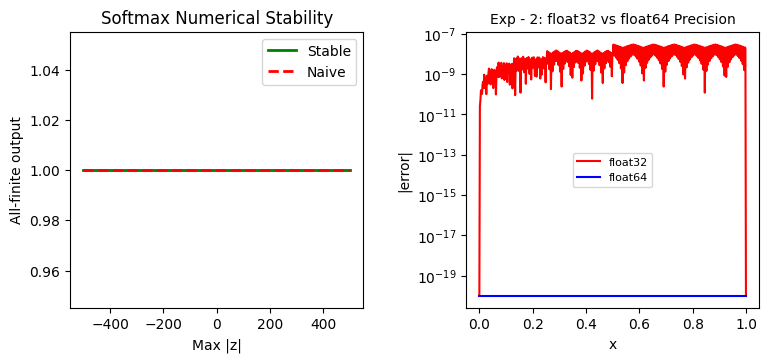

In [23]:

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax3   = fig.add_subplot(gs[0, 1])
z_vals = np.linspace(-500, 500, 200)
naive_ok  = []
stable_ok = []
for z in z_vals:
    inp = np.array([z, 0., -z])
    s   = softmax_stable(inp)
    try:
        n = softmax_naive(inp)
        naive_ok.append(np.isfinite(n).all())
    except:
        naive_ok.append(False)
    stable_ok.append(np.isfinite(s).all())
ax3.plot(z_vals, stable_ok, label='Stable', color='green',  lw=2)
ax3.plot(z_vals, naive_ok,  label='Naive',  color='red', lw=2, linestyle='--')
ax3.set_xlabel('Max |z|'); ax3.set_ylabel('All-finite output')
ax3.set_title('Softmax Numerical Stability')
ax3.legend()

ax  = fig.add_subplot(gs[0, 2])
xp  = np.linspace(0, 1, 500)
ax.semilogy(xp, np.abs(xp.astype(np.float32)-xp)+1e-20, label='float32', color='red')
ax.semilogy(xp, np.abs(xp.astype(np.float64)-xp)+1e-20, label='float64', color='blue')
ax.set_xlabel('x'); ax.set_ylabel('|error|')
ax.set_title('Exp - 2: float32 vs float64 Precision', fontsize=10)
ax.legend(fontsize=8)


---
## 7. Analysis & Discussion

**Tensor Operations:** Reshaping and broadcasting worked as expected. The batch norm analogy demonstrated how subtracting a `(4,)` mean from a `(32,4)` tensor broadcasts correctly — the same mechanism used in real normalisation layers.

**Matrix Multiplication:** The manual triple-loop confirmed the O(m·k·n) formula and matched NumPy/PyTorch results. Element-wise `*` vs matrix `@` is a common source of bugs beginners should watch for.

**Eigenvalues:** PC1 explains the dominant share of variance in the covariance matrix. Near-zero eigenvalues signal near-singular matrices, which is a concern in second-order optimisers.

**Numerical Instability:** Naive softmax produced `inf`/`nan` for large inputs. The stable version handled all cases. float32 introduces rounding errors ~1e-7 vs float64's ~1e-15, making careful initialisation important in training.

**NumPy vs PyTorch:** Both share the same tensor semantics and broadcasting rules. PyTorch's key advantage is autograd — essential for backpropagation, which NumPy cannot do.


---
## 8. Conclusion

- Tensors are the core data structure in deep learning; understanding shape and dtype prevents the majority of common bugs.
- Broadcasting enables efficient vectorised operations and is foundational to how layers like batch normalisation work.
- Eigenvalue decomposition reveals variance structure in data and directly underpins PCA-style preprocessing.
- Numerical instability (overflow, cancellation) is a real problem in training; stable implementations like log-sum-exp are standard practice.
- PyTorch extends NumPy with GPU support and autograd, making it the standard tool for building and training neural networks.